# Week 4: Cox-Ross-Rubinstein (CRR) Option Pricing Model

### Author: Ishika Rawat

This notebook implements the Cox-Ross-Rubinstein (CRR) Binomial Tree Model for pricing European and American put options. It also includes convergence analysis, finance-based validation tests, an American put price surface, and the early exercise boundary.

In [42]:
from crr_option_pricing import crr_put_price
from convergence import run_convergence
from tests import run_all_tests
from price_surface import generate_surface
from exercise_boundary import plot_boundary

import numpy as np
import matplotlib.pyplot as plt

In [43]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.25
steps = 500

european = crr_put_price(
    S0, K, T, r, sigma, steps, american=False
)

american = crr_put_price(
    S0, K, T, r, sigma, steps, american=True
)

print("European Put :", european)
print("American Put :", american)
print("Early Exercise Premium :", american - european)

European Put : 7.45399852394807
American Put : 7.972371262310154
Early Exercise Premium : 0.5183727383620838


## Convergence Analysis

The Cox-Ross-Rubinstein (CRR) model approximates the continuous-time option pricing model by dividing the option's life into discrete time steps. As the number of steps increases, the estimated option price converges to its true value. This section analyses the convergence behaviour of both European and American put options.

CRR CONVERGENCE STUDY
Steps = 25    European = 7.549650 American = 8.052667 Premium = 0.503017
Steps = 50    European = 7.409627 American = 7.952030 Premium = 0.542403
Steps = 100   European = 7.434252 American = 7.963611 Premium = 0.529359
Steps = 200   European = 7.446589 American = 7.969091 Premium = 0.522502
Steps = 500   European = 7.453999 American = 7.972371 Premium = 0.518373
Steps = 1000  European = 7.456470 American = 7.973439 Premium = 0.516969

Convergence table saved to: tables/convergence_table.csv
Figure saved to: figures/convergence.png

Interpretation
As the number of time steps increases, both prices stabilise. The American put consistently remains above the European put, and the gap converges to the early exercise premium.


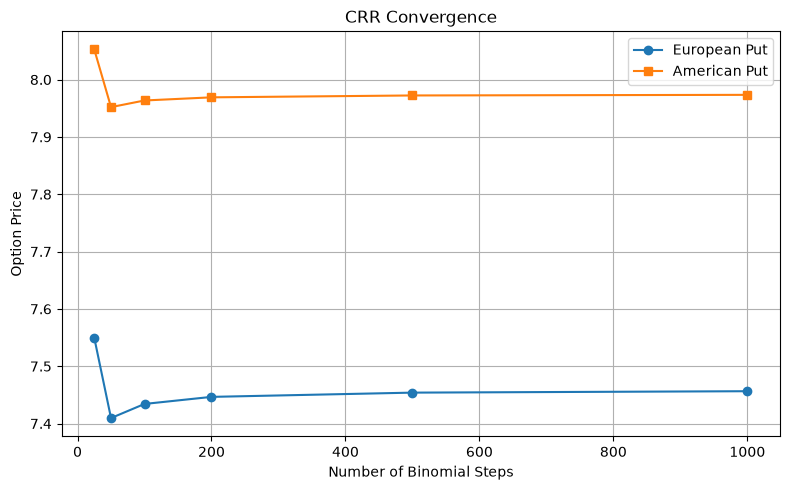

In [44]:
run_convergence()

## Finance-Based Sanity Tests

Before using the pricing model for analysis, it is important to verify that it satisfies the theoretical properties of option pricing. The following tests confirm that the implementation behaves consistently with financial intuition.

In [45]:
run_all_tests()

CRR OPTION PRICING SANITY TESTS
European Put : 7.453999
American Put : 7.972371
American put price >= European put price............... PASS
Intrinsic Value : 10.000000
American Put    : 13.042362
American put >= intrinsic value........................ PASS

Stock Price -> Put Value
 80 -> 20.362458
 90 -> 13.042362
100 -> 7.972371
110 -> 4.680430
120 -> 2.649422
Put value decreases as stock price increases........... PASS

Volatility -> Put Value
0.10 -> 2.435971
0.20 -> 6.088810
0.30 -> 9.867327
0.40 -> 13.663545
Put value increases with volatility.................... PASS

Steps -> American Put
 100 -> 7.963611
 200 -> 7.969091
 500 -> 7.972371
1000 -> 7.973439
Price converges as steps increase...................... PASS

Passed 5 out of 5 tests.
All sanity checks passed.


## American Put Price Surface

The following visualization illustrates how the value of an American put option changes with the initial stock price and the time remaining until expiration. As expected, the option becomes more valuable when the stock price falls and when more time remains before maturity.

Generating American Put Price Surface

Surface saved successfully.
Location: figures/price_surface.png


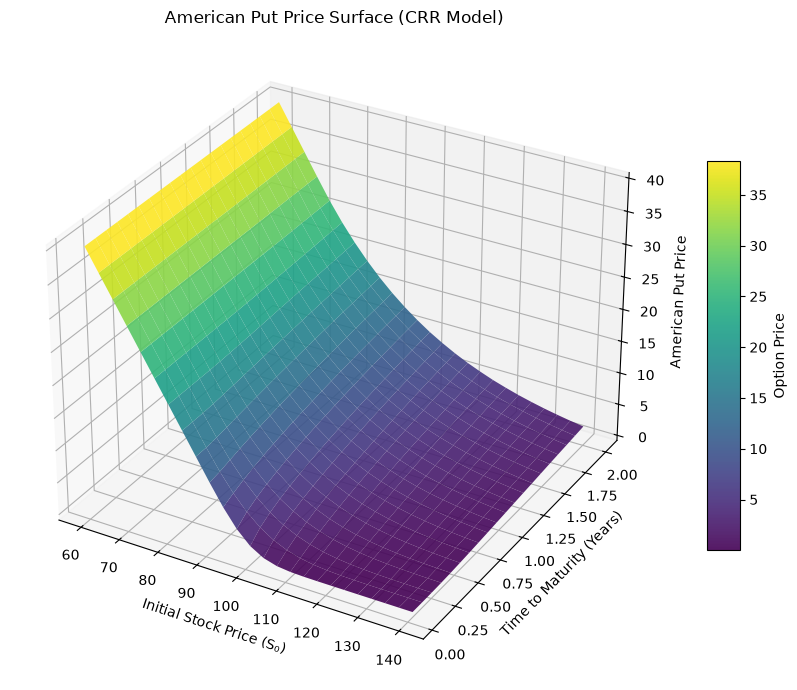

In [46]:
generate_surface()

## Early Exercise Boundary

Unlike European options, American options may be exercised before maturity. The early exercise boundary identifies the combinations of stock price and time where exercising immediately becomes more valuable than holding the option.

Generating Exercise Boundary

Exercise boundary saved as:
figures/exercise_boundary.png


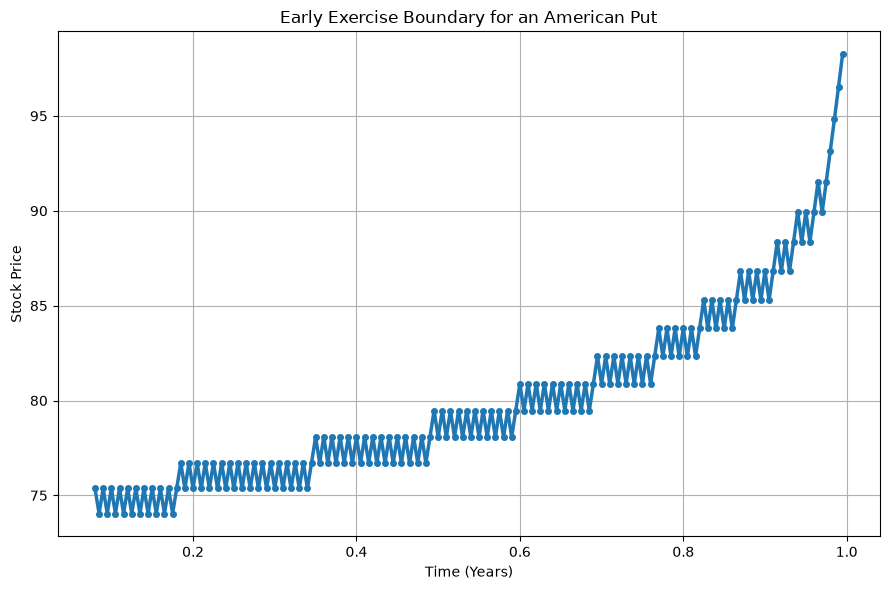

In [47]:
plot_boundary()

# Conclusion

This notebook presented a complete implementation of the Cox-Ross-Rubinstein (CRR) binomial tree model for pricing European and American put options. The implementation successfully priced both option types, analysed convergence behaviour, validated the model using finance-based sanity checks, generated a three-dimensional price surface, and identified the early exercise boundary.

The results demonstrate that American put options are consistently more valuable than European put options because of the flexibility of early exercise. The modular implementation developed in this project provides a strong foundation for future work, including Black-Scholes pricing, Monte Carlo simulation, implied volatility estimation, and option Greeks.